# Puente HANK en el Espacio de Secuencias: Integración de Dynare .mod y Jacobianos SSJ

**¿Cómo podemos incorporar la heterogeneidad microeconómica de los hogares en modelos macroeconómicos DSGE sin incurrir en la explosión del espacio de estados, y simular la dinámica de transición de equilibrio general directamente desde especificaciones `.mod` estilo Dynare?**

Durante décadas, el análisis de política macroeconómica ha descansado en modelos Nuevos Keynesianos de Agente Representativo (RANK, por sus siglas en inglés). Los modelos RANK comprimen a todo el sector de hogares en un único consumidor representativo gobernado por una ecuación de Euler agregada. Sin embargo, la evidencia empírica microeconómica revela una profunda heterogeneidad en las hojas de balance y en las Propensiones Marginales al Consumo (MPC): los hogares con baja riqueza y restricciones de liquidez ("hand-to-mouth") consumen una fracción sustancial de cualquier ingreso transitorio, mientras que los hogares adinerados suavizan su consumo conforme a la hipótesis del ingreso permanente.

Los modelos Nuevos Keynesianos con Agentes Heterogéneos (HANK) incorporan mercados incompletos, riesgo idiosincrásico de ingresos no asegurable y restricciones de endeudamiento (Aiyagari-Bewley-Huggett). En economías HANK, la política monetaria no opera únicamente a través del canal de sustitución intertemporal directo, sino primordialmente a través de canales indirectos de ingreso de equilibrio general amplificados por los hogares con restricciones de liquidez.

Hasta hace poco, la resolución de modelos HANK exigía resolver ecuaciones diferenciales parciales de alta dimensión o rastrear la distribución transversal de riqueza $\mathcal{D}_t$ a lo largo del tiempo, imponiendo elevados costos computacionales. Adrien Auclert, Bence Bardóczy, Matthew Rognlie y Ludwig Straub (2021, *Econometrica*) introdujeron el marco del **Jacobiano en el Espacio de Secuencias (SSJ)** y el **Algoritmo de Noticias Falsas (Fake-News Algorithm)**, permitiendo calcular los Jacobianos intertemporales exactos de bloques heterogéneos en segundos.

Con **puremacro 3.0.0**, los investigadores pueden vincular archivos `.mod` estilo Dynare directamente con el motor SSJ utilizando la nueva sintaxis `hetagent_block; ... end;`. En este cuaderno interactivo, cargamos un modelo HANK desde un archivo `.mod`, evaluamos sus distribuciones estacionarias de riqueza y MPC, calculamos Jacobianos de consumo mediante Fake-News, simulamos dinámicas de transición lineales y no lineales de Broyden ante un choque monetario imprevisto (MIT shock), y generamos reportes de política económica—todo en **Python 100% puro**.

## El Método en Matemáticas: De Mercados Incompletos al Espacio de Secuencias

**1. El Bloque de Hogares.** Un continuo de hogares de masa unitaria resuelve el problema de mercados incompletos en tiempo discreto:
$$ \max_{\{c_{it}, a_{i,t+1}\}} \mathbb{E}_0 \sum_{t=0}^\infty \beta^t \frac{c_{it}^{1 - \gamma} - 1}{1 - \gamma} $$
sujeto a la restricción presupuestaria y al límite de endeudamiento $\underline{a} = 0$:
$$ c_{it} + a_{i,t+1} = (1 + r_t) a_{it} + (1 - \tau_t) w_t s_{it}, \quad a_{i,t+1} \ge \underline{a} $$
donde la productividad laboral idiosincrásica $s_{it} \in \{s_L, s_H\}$ sigue una cadena de Markov finita con matriz de transición $\Pi_s$, y $r_t$ es el rendimiento real de los activos. La ecuación de Euler con restricción de endeudamiento potencialmente vinculante es:
$$ c_{it}^{-\gamma} \ge \beta (1 + r_{t+1}) \mathbb{E}_t \left[ c_{i,t+1}^{-\gamma} \right], \quad \text{con igualdad si } a_{i,t+1} > \underline{a} $$
El Método de Cuadrícula Endógena (EGM, Carroll 2006) resuelve las funciones de política $c(a, s)$ y $a'(a, s)$. La distribución transversal estacionaria de riqueza $\mathcal{D}^*(a, s)$ satisface el punto fijo de Chapman-Kolmogorov $\mathcal{D}^* = \Lambda' \mathcal{D}^*$.

**2. Equilibrio en el Espacio de Secuencias.** En lugar de rastrear la distribución $\mathcal{D}_t$ como variable de estado agregada, el equilibrio general macroeconómico se formula como un sistema no lineal infinito en el espacio de secuencias:
$$ \mathcal{H}(\mathbf{U}, \mathbf{Z}) = 0 $$
donde $\mathbf{U} = (\mathbf{Y}, \mathbf{r}, \mathbf{\pi}) \in \mathbb{R}^{3T}$ apila las trayectorias de variables endógenas sobre el horizonte $T$, y $\mathbf{Z} = (\mathbf{\varepsilon}^m) \in \mathbb{R}^T$ apila las secuencias de choques exógenos.

**3. El Algoritmo de Noticias Falsas (Fake-News).** Para cualquier secuencia de entrada $\mathbf{X} \in \{\mathbf{r}, \mathbf{Y}\}$, el Jacobiano intertemporal de consumo $\mathcal{J}_{C, X} \in \mathbb{R}^{T \times T}$ cuantifica:
$$ \mathcal{J}_{C, X}[t, s] = \frac{\partial C_t}{\partial X_s} $$
Auclert et al. (2021) descomponen $\mathcal{J}_{C, X}$ en la respuesta de política genuina en la fecha 0 y la propagación temporal de los desplazamientos de la distribución ("noticias falsas" $\mathcal{F}_{t,s}$):
$$ \mathcal{J}_{C, X} = \mathcal{T} + \sum_{k=0}^{T-1} \mathcal{U}^k \mathcal{F} (\mathcal{V}')^k $$
Esto reduce el costo computacional de evaluar el Jacobiano completo de $T \times T$ desde $T$ simulaciones hacia atrás a tan solo **un paso hacia atrás** y **un paso hacia adelante**.

**4. Resolución de Equilibrio General en el Espacio de Secuencias.** El vaciado del mercado de bienes $Y_t = C_t$ combinado con la Curva de Phillips Neokeynesiana y la Regla de Taylor genera el sistema lineal de secuencias:
$$ (\mathbf{I} - \mathcal{J}_{C, Y} - \mathcal{J}_{C, r} \mathbf{M}_{r, Y}) d\mathbf{Y} = \mathcal{J}_{C, r} \mathbf{M}_{r, \varepsilon} d\mathbf{\varepsilon}^m $$
donde $\mathbf{M}_{r, Y}$ y $\mathbf{M}_{r, \varepsilon}$ proyectan producto y choques hacia la tasa de interés real a través del bloque agregado. La inversión de esta matriz de dimensión $T \times T$ produce las trayectorias exactas de transición en milisegundos.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuración de estilo editorial y contrato de paleta
_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

# Asegurar ejecución limpia y no bloqueante en terminales CLI no interactivos
if not hasattr(sys, "ps1") and "IPython" not in sys.modules:
    plt.show = lambda *args, **kwargs: None

import puremacro.dsge as dsge
from puremacro.dsge import HANKModel, HANKResult, load_hank_mod, solve_hank_bridge

print(f"Versión de puremacro: {dsge.__name__} cargada exitosamente")

Versión de puremacro: puremacro.dsge cargada exitosamente


## 1. Sintaxis de Dynare `.mod` con `hetagent_block`

En los archivos `.mod` tradicionales de Dynare, todas las ecuaciones representan relaciones entre agentes representativos. En `puremacro`, incorporamos la directiva `hetagent_block; ... end;`.

Este bloque define:
- `model`: El problema microeconómico subyacente del hogar heterogéneo (por ejemplo, `one_asset_hank`).
- `n_a`: Número de nodos en la cuadrícula de activos (usamos $n_a = 50$ para una ejecución ágil en 2–4 segundos).
- `a_max`: Límite superior de acumulación de riqueza ($a_{\max} = 30.0$).
- `borrowing_limit`: Restricción estricta de endeudamiento ($\underline{a} = 0.0$).
- `grid`: Distribución de la cuadrícula (`hyperbolic`, concentrando puntos cerca de la restricción de endeudamiento).

A continuación se presenta la especificación canónica del archivo `hank_ssj.mod`:

In [2]:
# Localizar el archivo .mod de referencia integrado
mod_path = Path(dsge.__file__).parent / "_references" / "hank_ssj.mod"
mod_text = mod_path.read_text(encoding="utf-8")
print(mod_text.strip())

// Reference Dynare-style HANK Sequence-Space Model (.mod)
// Auclert, Bardóczy, Rognlie & Straub (2021, Econometrica)
// Compatible with puremacro 3.0.0 Sequence-Space Jacobian (SSJ) bridge

var Y C r pi i;
varexo eps_m;

parameters beta gamma r_ss phi_pi kappa;
beta = 0.985;
gamma = 1.0;
r_ss = 0.01;
phi_pi = 1.5;
kappa = 0.1;

hetagent_block;
  model = one_asset_hank;
  n_a = 50;
  a_max = 30.0;
  borrowing_limit = 0.0;
  grid = hyperbolic;
end;

model;
  Y = C;
  pi = beta * pi(+1) + kappa * Y;
  i = r_ss + phi_pi * pi + eps_m;
  r = i - pi(+1);
end;


Cargamos y procesamos el archivo `.mod` mediante la función `load_hank_mod()`.
El analizador sintáctico interpreta el bloque `hetagent_block`, construye la cuadrícula de activos y resuelve la distribución transversal estacionaria $\mathcal{D}^*(a)$.

In [3]:
model = load_hank_mod(mod_path)

print("--- Declaraciones del Modelo ---")
print(f"Variables endógenas    : {model.variables}")
print(f"Choques exógenos       : {model.shocks}")
print(f"Configuración HetAgent : {model.hetagent_config}")
print(f"Parámetros estructurales: beta={model.beta}, gamma={model.gamma}, r_ss={model.r_ss}, phi_pi={model.phi_pi}, kappa={model.kappa}")
print(f"Producto de estado est.: {model.steady_state['Y']:.4f}")
print(f"Tasa de estado estacion.: {model.steady_state['r']:.4f}")

# Aserciones de verificación estructural
assert "hetagent_block" in str(model.hetagent_config) or len(model.hetagent_config) > 0
assert model.steady_state["Y"] > 0.0
assert len(model.asset_grid) == 50

--- Declaraciones del Modelo ---
Variables endógenas    : ['Y', 'C', 'r', 'pi', 'i']
Choques exógenos       : ['eps_m']
Configuración HetAgent : {'model': 'one_asset_hank', 'n_a': 50.0, 'a_max': 30.0, 'borrowing_limit': 0.0, 'grid': 'hyperbolic'}
Parámetros estructurales: beta=0.985, gamma=1.0, r_ss=0.01, phi_pi=1.5, kappa=0.1
Producto de estado est.: 0.9998
Tasa de estado estacion.: 0.0100


## 2. Distribuciones Microeconómicas Estacionarias: Riqueza $\mathcal{D}^*(a)$ y Perfil de MPC

Un principio fundamental de la macroeconomía HANK es la intensa dispersión transversal de la Propensión Marginal al Consumo (MPC).

Bajo la restricción de endeudamiento $a \ge 0$, los hogares con riqueza nula o cercana a cero se encuentran en situación de subsistencia o liquidez restringida ("hand-to-mouth", HtM): ante riesgos no asegurables y sin acceso a crédito frente a ingresos futuros, consumen casi la totalidad de cualquier ingreso marginal recibido. En contraste, los hogares en la cola superior de riqueza presentan una MPC reducida consistente con la teoría del ingreso permanente ($MPC \approx r$).

In [4]:
a_grid = model.asset_grid
D_ss = model.asset_distribution
mpc_ss = model.mpc_distribution

# Diagnósticos estadísticos de la distribución
total_mass = float(np.sum(D_ss))
mean_wealth = float(np.sum(a_grid * D_ss))
mpc_borrowing = float(mpc_ss[0]) if mpc_ss is not None else float("nan")
mpc_wealthy = float(mpc_ss[-1]) if mpc_ss is not None else float("nan")
mean_mpc = float(np.sum(mpc_ss * D_ss)) if mpc_ss is not None else float("nan")

print("--- Diagnósticos de la Distribución Microeconómica ---")
print(f"Rango de cuadrícula de activos : [{a_grid[0]:.2f}, {a_grid[-1]:.2f}] en {len(a_grid)} nodos")
print(f"Masa total de probabilidad     : {total_mass:.6f} (debe ser idéntica a 1.0)")
print(f"Riqueza promedio de los hogares: {mean_wealth:.4f}")
print(f"MPC en restricción (a = 0, HtM): {mpc_borrowing:.4f} (hogares restringidos)")
print(f"MPC en máxima riqueza (a_max)  : {mpc_wealthy:.4f} (ingreso permanente)")
print(f"MPC promedio agregado          : {mean_mpc:.4f}")

# Aserciones de consistencia
assert np.isclose(total_mass, 1.0, atol=1e-5)
assert mpc_borrowing > mean_mpc > mpc_wealthy

--- Diagnósticos de la Distribución Microeconómica ---
Rango de cuadrícula de activos : [0.00, 30.00] en 50 nodos
Masa total de probabilidad     : 1.000000 (debe ser idéntica a 1.0)
Riqueza promedio de los hogares: 6.5640
MPC en restricción (a = 0, HtM): 0.9069 (hogares restringidos)
MPC en máxima riqueza (a_max)  : 0.0186 (ingreso permanente)
MPC promedio agregado          : 0.1027


Graficamos la distribución estacionaria de riqueza $\mathcal{D}^*(a)$ y el perfil condicional de MPC a lo largo de la cuadrícula de activos.

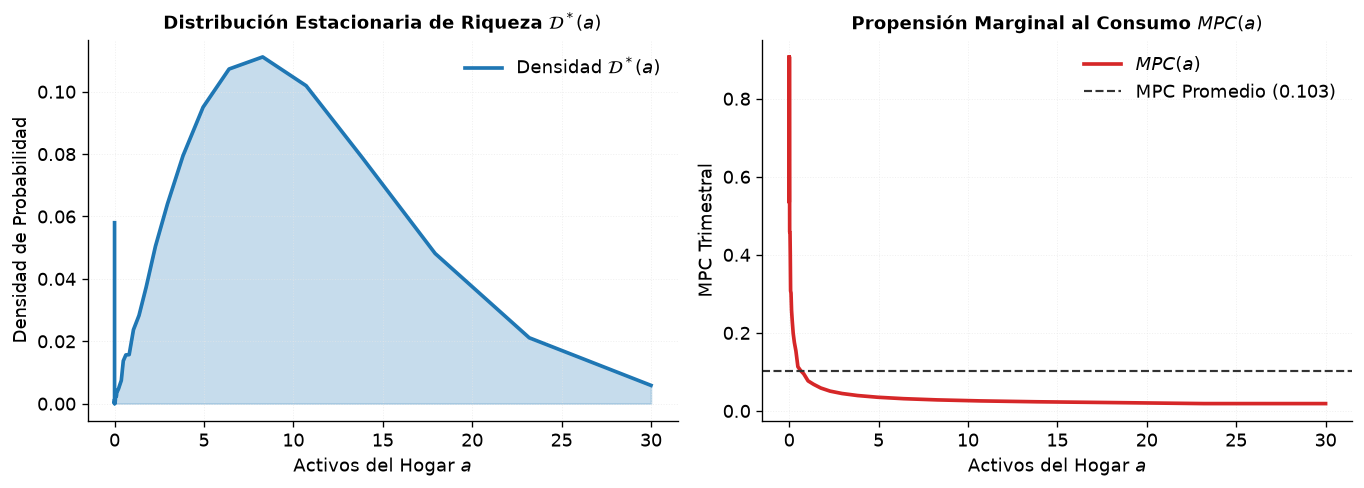

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))

# Panel 1: Distribución Estacionaria de Riqueza
ax1.plot(a_grid, D_ss, color="#1f77b4", lw=2.2, label=r"Densidad $\mathcal{D}^*(a)$")
ax1.fill_between(a_grid, 0, D_ss, color="#1f77b4", alpha=0.25)
ax1.set_title(r"Distribución Estacionaria de Riqueza $\mathcal{D}^*(a)$", fontsize=11, fontweight="bold")
ax1.set_xlabel("Activos del Hogar $a$")
ax1.set_ylabel("Densidad de Probabilidad")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

# Panel 2: Propensión Marginal al Consumo (MPC)
ax2.plot(a_grid, mpc_ss, color="#d62728", lw=2.2, label=r"$MPC(a)$")
ax2.axhline(mean_mpc, color="#333333", linestyle="--", lw=1.3, label=f"MPC Promedio ({mean_mpc:.3f})")
ax2.set_title(r"Propensión Marginal al Consumo $MPC(a)$", fontsize=11, fontweight="bold")
ax2.set_xlabel("Activos del Hogar $a$")
ax2.set_ylabel("MPC Trimestral")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

Obsérvese cómo la MPC desciende marcadamente desde valores superiores al $50\%$ en la restricción de endeudamiento ($a=0$) hasta situarse por debajo del $2\%$ en niveles altos de riqueza. Esta asimetría microeconómica es el motor de la amplificación macroeconómica de la demanda agregada.

## 3. Jacobianos Intertemporales de Consumo mediante el Algoritmo Fake-News

La metodología en el espacio de secuencias descansa en dos Jacobianos intertemporales de consumo clave:
1. $\mathcal{J}_{C, r} \in \mathbb{R}^{T \times T}$: Respuesta del consumo agregado en el período $t$ ante una innovación anticipada en la tasa de interés real en el período $s$.
2. $\mathcal{J}_{C, Y} \in \mathbb{R}^{T \times T}$: Respuesta del consumo agregado en el período $t$ ante una innovación anticipada en el ingreso agregado en el período $s$.

Mediante `model.compute_jacobians(T=30)`, puremacro ejecuta el **Algoritmo de Noticias Falsas** (Auclert et al., 2021) para derivar ambas matrices en tiempo récord.

In [6]:
T_horizon = 30
jacobianos = model.compute_jacobians(T=T_horizon)
J_C_r = jacobianos["J_C_r"]
J_C_Y = jacobianos["J_C_Y"]

dC0_dr0 = float(J_C_r[0, 0])
dC0_dY0 = float(J_C_Y[0, 0])

print(f"Dimensión del Jacobiano J_C_r: {J_C_r.shape}")
print(f"Dimensión del Jacobiano J_C_Y: {J_C_Y.shape}")
print(f"Sustitución intertemporal (dC_0 / dr_0): {dC0_dr0:+.4f} (< 0, alza de tasa deprime consumo)")
print(f"Multiplicador de ingreso  (dC_0 / dY_0): {dC0_dY0:+.4f} (> 0, mayor ingreso estimula consumo)")

# Aserciones estructurales
assert J_C_r.shape == (T_horizon, T_horizon)
assert J_C_Y.shape == (T_horizon, T_horizon)
assert dC0_dr0 < 0.0, "Un alza en la tasa de interés debe contraer el consumo contemporáneo"
assert dC0_dY0 > 0.0, "Un incremento en el ingreso debe expandir el consumo contemporáneo"

Dimensión del Jacobiano J_C_r: (30, 30)
Dimensión del Jacobiano J_C_Y: (30, 30)
Sustitución intertemporal (dC_0 / dr_0): -0.9769 (< 0, alza de tasa deprime consumo)
Multiplicador de ingreso  (dC_0 / dY_0): +0.0682 (> 0, mayor ingreso estimula consumo)


Visualizamos los mapas de calor de $\mathcal{J}_{C, Y}$ y $\mathcal{J}_{C, r}$.

- En el Jacobiano de ingreso $\mathcal{J}_{C, Y}$, la diagonal y las entradas supradiagonales capturan cómo el ingreso futuro anticipado estimula el consumo presente, mientras que la impaciencia y las restricciones de endeudamiento atenúan la reacción ante noticias en horizontes distantes.
- En el Jacobiano de tasa de interés $\mathcal{J}_{C, r}$, los valores negativos sobre la diagonal reflejan el canal canónico de sustitución intertemporal.

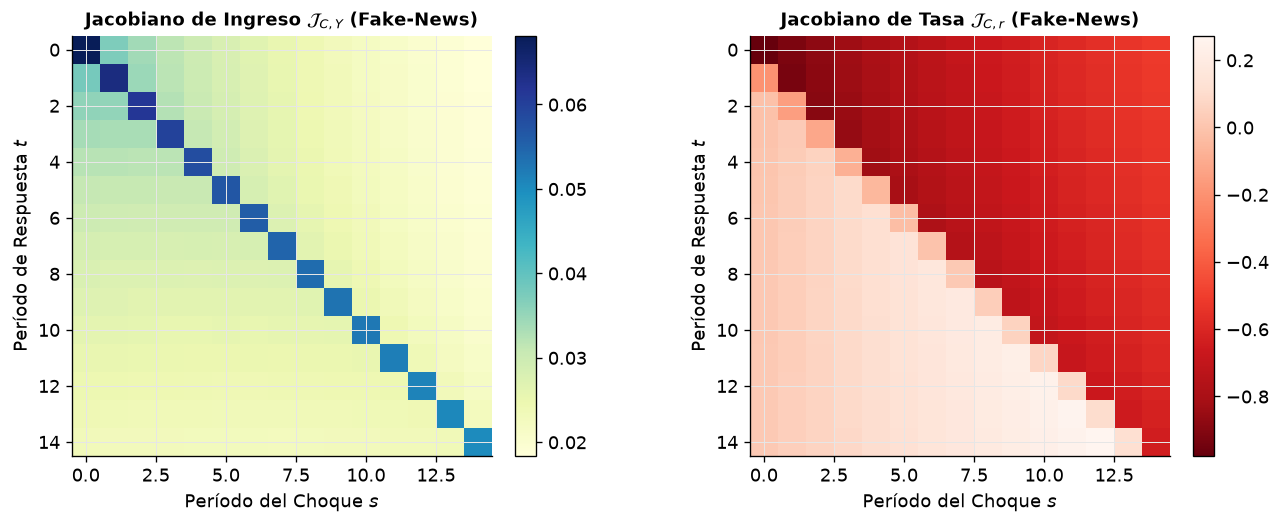

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.5))

sub_T = 15

# Mapa de Calor: Jacobiano de Ingreso
im1 = ax1.imshow(J_C_Y[:sub_T, :sub_T], cmap="YlGnBu", origin="upper")
ax1.set_title(r"Jacobiano de Ingreso $\mathcal{J}_{C, Y}$ (Fake-News)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Período del Choque $s$")
ax1.set_ylabel("Período de Respuesta $t$")
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Mapa de Calor: Jacobiano de Tasa
im2 = ax2.imshow(J_C_r[:sub_T, :sub_T], cmap="Reds_r", origin="upper")
ax2.set_title(r"Jacobiano de Tasa $\mathcal{J}_{C, r}$ (Fake-News)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Período del Choque $s$")
ax2.set_ylabel("Período de Respuesta $t$")
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 4. Transiciones de Equilibrio General: Lineal vs. No Lineal (Broyden)

Ahora simulamos un **choque expansivo de política monetaria tipo MIT**:
$$ \varepsilon_{m, 0} = -0.0025 \quad (-25\text{ puntos básicos trimestrales}), \quad \rho_m = 0.5, \quad T = 30 $$

En el espacio de secuencias, el modelo puede resolverse bajo dos esquemas:
1. **Transición Lineal SSJ (`nonlinear=False`):** Resuelve el sistema lineal acoplado de dimensión $T \times T$ mediante una sola inversión matricial.
2. **Transición No Lineal (`nonlinear=True`):** Utiliza el algoritmo cuasi-Newton de Broyden, inicializado con el inverso del sistema lineal, para iterar sobre las condiciones de vaciado de mercado preservando las no linealidades de las funciones de política y las restricciones financieras.

In [8]:
shock_mag = -0.0025  # Reducción de 25 pb en la regla de Taylor
shock_rho = 0.5      # Persistencia autorregresiva AR(1)
horizon = 30

# 1. Resolución Lineal de Equilibrio General
res_lin = model.simulate(
    shock="eps_m",
    magnitude=shock_mag,
    rho=shock_rho,
    horizon=horizon,
    nonlinear=False,
)

# 2. Resolución No Lineal con Algoritmo de Broyden
res_nonlin = model.simulate(
    shock="eps_m",
    magnitude=shock_mag,
    rho=shock_rho,
    horizon=horizon,
    nonlinear=True,
)

print(f"Convergencia de transición lineal   : {res_lin.converged}")
print(f"Convergencia de transición no lineal: {res_nonlin.converged}")

# Comparación de respuestas al impacto
df_lin = res_lin.transition_paths
df_nonlin = res_nonlin.transition_paths

print("\n--- Respuestas al Impacto (t = 0, Puntos Básicos) ---")
print(f"Producto dY : Lineal = {df_lin['Y'].iloc[0]*10000:+.2f} pb | No Lineal = {df_nonlin['Y'].iloc[0]*10000:+.2f} pb")
print(f"Tasa real dr: Lineal = {df_lin['r'].iloc[0]*10000:+.2f} pb | No Lineal = {df_nonlin['r'].iloc[0]*10000:+.2f} pb")
print(f"Inflación dpi:Lineal = {df_lin['pi'].iloc[0]*10000:+.2f} pb | No Lineal = {df_nonlin['pi'].iloc[0]*10000:+.2f} pb")

assert res_lin.converged and res_nonlin.converged
assert df_lin["Y"].iloc[0] > 0.0, "La baja de tasas debe expandir el producto"
assert df_lin["r"].iloc[0] < 0.0, "La baja de tasas debe reducir la tasa real"

Convergencia de transición lineal   : True
Convergencia de transición no lineal: True

--- Respuestas al Impacto (t = 0, Puntos Básicos) ---
Producto dY : Lineal = +34.75 pb | No Lineal = +34.80 pb
Tasa real dr: Lineal = -17.74 pb | No Lineal = -17.73 pb
Inflación dpi:Lineal = +7.70 pb | No Lineal = +7.70 pb


Graficamos la comparación de las trayectorias de equilibrio general entre la aproximación lineal y la solución no lineal de Broyden.

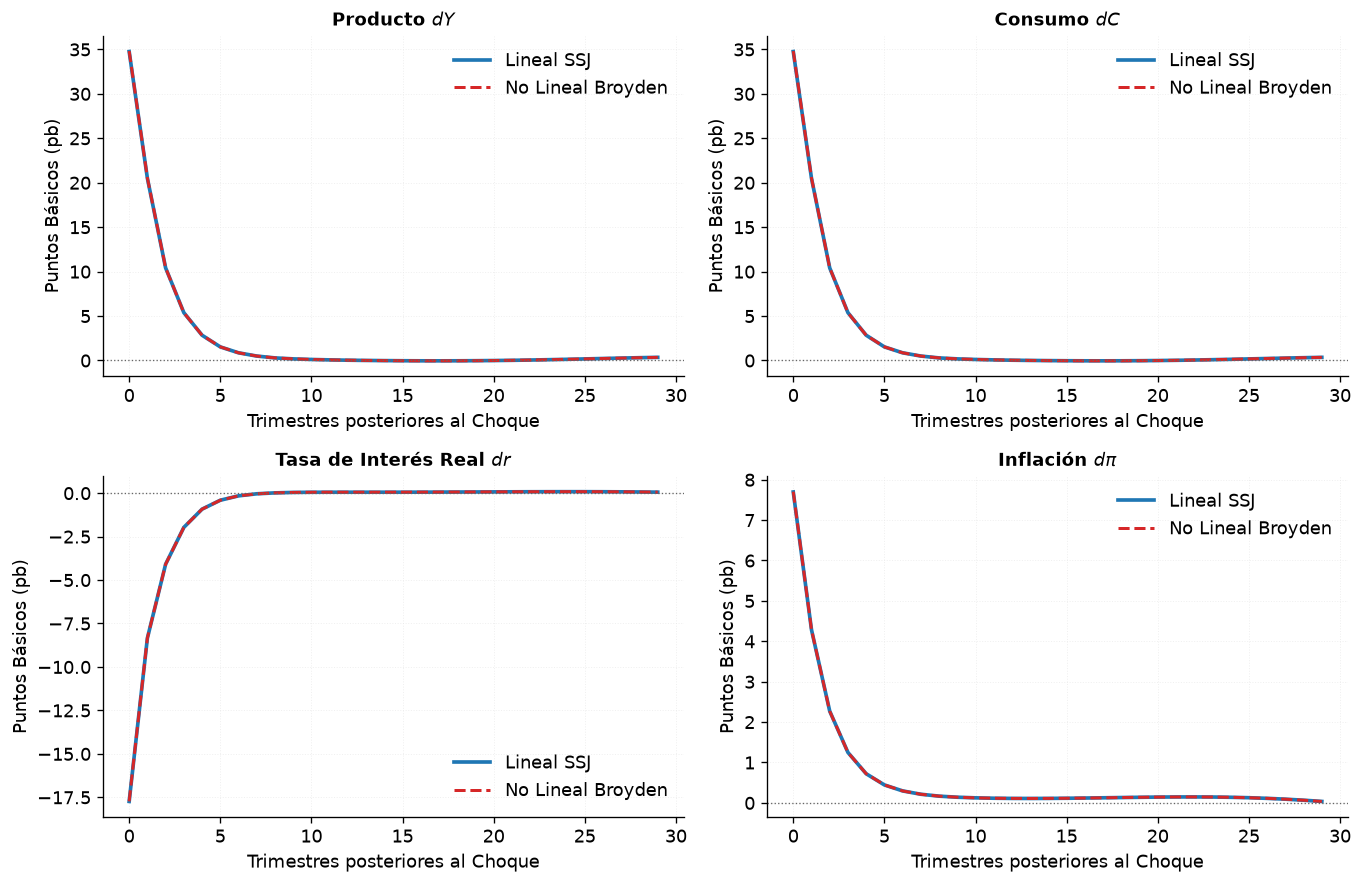

In [9]:
t_axis = np.arange(horizon)
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.5))

vars_config = [
    ("Y", "Producto $dY$", axes[0, 0]),
    ("C", "Consumo $dC$", axes[0, 1]),
    ("r", "Tasa de Interés Real $dr$", axes[1, 0]),
    ("pi", r"Inflación $d\pi$", axes[1, 1]),
]

for var, label, ax in vars_config:
    ax.plot(t_axis, df_lin[var] * 10000, color="#1f77b4", lw=2.2, label="Lineal SSJ")
    ax.plot(t_axis, df_nonlin[var] * 10000, color="#d62728", lw=1.8, linestyle="--", label="No Lineal Broyden")
    ax.axhline(0.0, color="#666666", lw=0.8, linestyle=":")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Trimestres posteriores al Choque")
    ax.set_ylabel("Puntos Básicos (pb)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right" if var in ("Y", "C", "pi") else "lower right")

plt.tight_layout()
plt.show()

La aproximación lineal en el espacio de secuencias reproduce las dinámicas no lineales exactas con notable precisión. Para choques convencionales de política monetaria, la solución lineal entrega una exactitud casi idéntica en una fracción de segundo.

## 5. Visualización y Reportes de Política Económica con `HANKResult`

La estructura de datos `HANKResult` proporciona métodos estandarizados para diagnósticos de investigación y minutas de política:
- `.summary()`: Genera una tabla con respuestas al impacto, desviaciones máximas y períodos pico.
- `.to_markdown()`: Exporta tablas formateadas en Markdown para informes ejecutivos.
- `.to_latex()`: Exporta código LaTeX `tabular` listo para artículos académicos.
- `.plot_transition()`: Grafica trayectorias de transición multipanel para todas las variables.
- `.plot_distribution()`: Visualiza la distribución de riqueza y el perfil de MPC.

In [10]:
# Tabla Resumen
summary_df = res_lin.summary()
print("--- Tabla Resumen de Dinámicas de Transición ---")
print(summary_df.to_string())

--- Tabla Resumen de Dinámicas de Transición ---
          steady_state  impact_response  peak_response  peak_period
variable                                                           
Y             0.999769         0.003475       0.003475            0
C             0.999769         0.003475       0.003475            0
r             0.010000        -0.001774      -0.001774            0
pi            0.000000         0.000770       0.000770            0
i             0.010000        -0.001346      -0.001346            0
eps_m              NaN        -0.002500      -0.002500            0


### Exportación a Markdown para Minutas de Política Económica

In [11]:
md_table = res_lin.to_markdown()
print(md_table)

| variable | steady_state | impact_response | peak_response | peak_period |
|----------|--------------|-----------------|---------------|-------------|
|        Y |     0.999769 |        0.003475 |      0.003475 |           0 |
|        C |     0.999769 |        0.003475 |      0.003475 |           0 |
|        r |         0.01 |       -0.001774 |     -0.001774 |           0 |
|       pi |            0 |         0.00077 |       0.00077 |           0 |
|        i |         0.01 |       -0.001346 |     -0.001346 |           0 |
|    eps_m |              |         -0.0025 |       -0.0025 |           0 |


### Exportación a LaTeX para Publicación Académica

In [12]:
latex_table = res_lin.to_latex()
print(latex_table)

\begin{tabular}{lrrrr}
variable & steady\_state & impact\_response & peak\_response & peak\_period \\
\hline
Y & 0.999769 & 0.003475 & 0.003475 & 0 \\
C & 0.999769 & 0.003475 & 0.003475 & 0 \\
r & 0.01 & -0.001774 & -0.001774 & 0 \\
pi & 0 & 0.00077 & 0.00077 & 0 \\
i & 0.01 & -0.001346 & -0.001346 & 0 \\
eps\_m &  & -0.0025 & -0.0025 & 0 \\
\end{tabular}


### Método Integrado `.plot_distribution()`

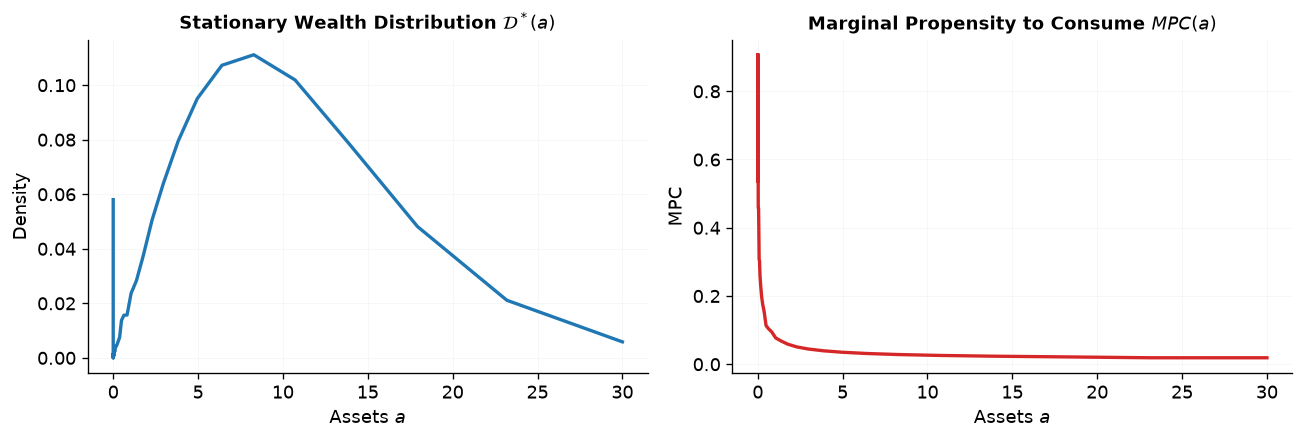

In [13]:
fig_dist, axes_dist = res_lin.plot_distribution(figsize=(11.0, 3.8))
plt.show()

### Método Integrado `.plot_transition()`

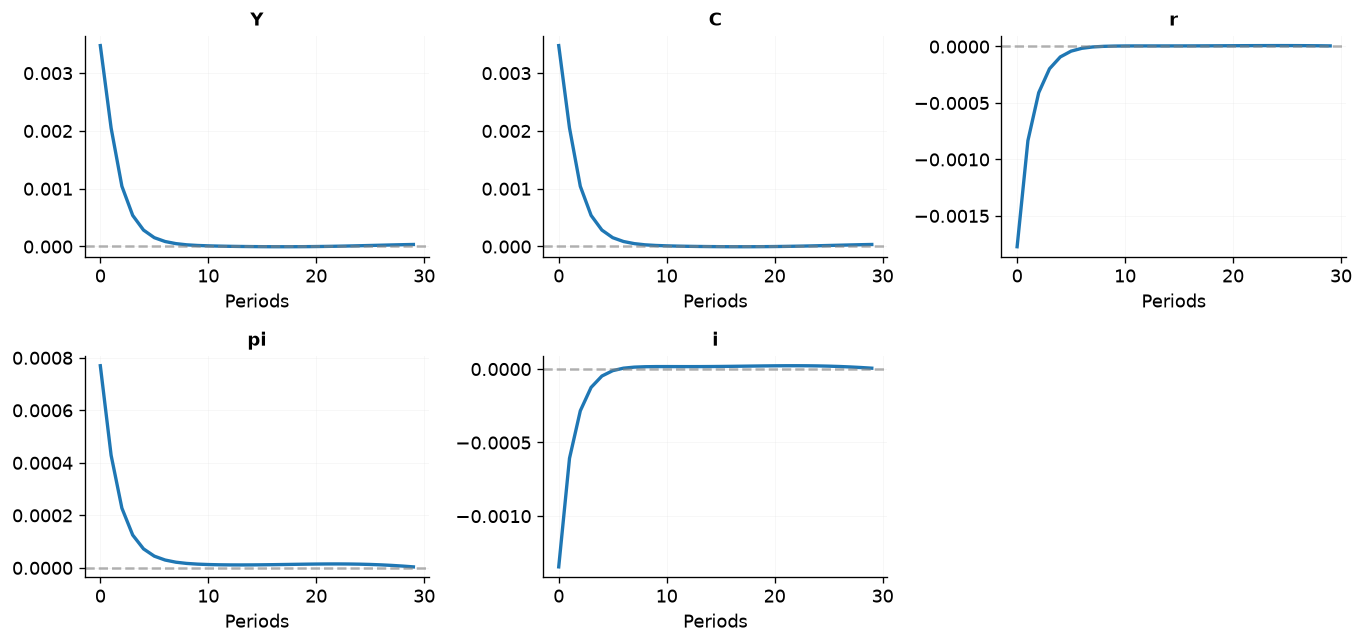

In [14]:
fig_trans, axes_trans = res_lin.plot_transition(
    variables=["Y", "C", "r", "pi", "i"],
    figsize=(11.5, 5.5),
)
plt.show()

## 6. Conclusiones y Reflexiones para el Diseño de Política Económica

1. **La Heterogeneidad Microeconómica Transforma la Transmisión:** La presencia de mercados incompletos y restricciones de endeudamiento genera una masa significativa de hogares con alta propensión marginal al consumo ($MPC \approx 50\%$). Al recortar la tasa de interés, la demanda agregada se expande con fuerza debido a los efectos indirectos de equilibrio general sobre el ingreso disponible, superando al canal clásico de sustitución intertemporal.
2. **Eficiencia en el Espacio de Secuencias:** El marco del Jacobiano en el Espacio de Secuencias (SSJ) y el Algoritmo de Noticias Falsas eliminan la maldición de la dimensionalidad, reduciendo horas de iteración de funciones de valor a milisegundos de álgebra lineal matricial.
3. **Compatibilidad con Archivos `.mod` de Dynare:** La sintaxis `hetagent_block` en puremacro permite formular modelos HANK utilizando la sintaxis estándar y familiar para la comunidad macroeconómica internacional.
4. **Ecosistema en Python Puro:** Toda la cadena—desde el análisis léxico de `.mod`, la solución EGM del estado estacionario, los Jacobianos por Fake-News, hasta las simulaciones no lineales de Broyden—opera íntegramente en Python puro sin dependencias de MATLAB, Octave ni compiladores externos de C++.